# Partition Generator
**Purpose:** Given a large playlist, partition into k smaller playlists by clustering on features. 

**Features:** BPM, Valence, Dance, Energy, Acoustic, Album Year, Popularity

**Steps:** 
1. Select k clusters
2. Get partition params
3. Partition using best k and params

## Import Libraries

In [2]:
# Import necessary libraries for cluster analysis and visualization
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples
from itertools import combinations

## Read Data

In [3]:
df_playlist = pd.read_csv('../data/mixed_playlist.csv')
df_playlist

,Song,Artist,BPM,Camelot,Energy,Added At,Duration,Popularity,Genres,Album,...,Valence,Speech,Live,Loud (Db),Key,Time Signature,Spotify Track Id,ISRC,Playlist,Album Year
0,&Run,Sir Sly,92,7B,66,2026-03-02,03:46,61,NaN,"Don't You Worry, Honey",...,48,0,10,-8,F Major,4,0w4m3Xp4svlIoyL94Zjlyd,USUM71704895,Liked Songs,2017
1,..FEISTY,"Fred again..,BIA",204,3B,71,2026-03-01,02:51,54,"stutter house, house, edm,",..FEISTY,...,56,30,30,-5,C♯/D♭ Major,4,5RMlUiY2og97DronMz3GlG,GBAHS2501368,Liked Songs,2025
2,.intoodeep.,Dead Poet Society,125,4B,68,2026-03-30,03:39,56,NaN,-!- (Deluxe),...,49,0,30,-6,G#/A♭ Major,4,54jvLVojOWiQRubRfKmZ2k,GBUM72003959,Liked Songs,2021
3,12 to 12,sombr,124,10A,90,2026-03-02,04:02,92,NaN,I Barely Know Her,...,51,0,10,-3,B Minor,4,05od2qm2MTSKCHxy1GBp5W,USWB12502453,Liked Songs,2025
4,16 Years,Phantogram,120,11A,78,2026-04-05,03:56,41,NaN,Nightlife,...,19,0,40,-6,F#/G♭ Minor,4,1R7EfuL60uDJSvGndrH7Np,USBS51131292,Liked Songs,2011
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1377,when the party's over,Billie Eilish,83,12B,11,2026-04-05,03:16,86,NaN,"WHEN WE ALL FALL ASLEEP, WHERE DO WE GO?",...,20,10,0,-14,E Major,4,43zdsphuZLzwA9k4DJhU0I,USUM71815958,Liked Songs,2019
1378,wish you were gay,Billie Eilish,118,9B,35,2026-04-05,03:41,75,NaN,"WHEN WE ALL FALL ASLEEP, WHERE DO WE GO?",...,28,20,70,-10,G Major,4,3Fj47GNK2kUF0uaEDgXLaD,USUM71900767,Liked Songs,2019
1379,yeti,"Paris Paloma,Old Sea Brigade",139,10A,39,2026-03-30,04:12,49,"indie folk, folk pop",Cacophony,...,25,0,10,-11,B Minor,4,09cCZPsr05CpO15RgnHCr7,CAN112300618,Liked Songs,2024
1380,you should see me in a crown,Billie Eilish,150,12B,53,2026-03-02,03:00,77,NaN,"WHEN WE ALL FALL ASLEEP, WHERE DO WE GO?",...,32,10,10,-10,E Major,4,3XF5xLJHOQQRbWya6hBp7d,USUM71810049,Liked Songs,2019


## Environment Variables

In [3]:
# === CONFIG ===
METADATA = ['Spotify Track Id', 'Song', 'Artist', 'Album', 'Playlist']
FEATURES = ['BPM', 'Dance', 'Energy', 'Valence', 'Acoustic', 'Loud (Db)', 'Album Year', 'Popularity']
FEATURE_WEIGHTS = {'Valence': 3, 'Dance': 2}
TARGET_MIN = 25 # smallest playlist size 
TARGET_MAX = 50 # largest playlist size

# === N CLUSTERS ===
n_songs = len(df_playlist)
k_min = n_songs // TARGET_MAX  
k_max = n_songs // TARGET_MIN 
k_range = range(k_min, k_max + 1)

# === PREPARE DATA ===
df_playlist['Album Year'] = df_playlist['Album Date'].str[:4].astype(int)
df_playlist_features = df_playlist[FEATURES]
df_playlist_metadata = df_playlist[METADATA + ['Album Year']]
df_playlist_results = df_playlist[METADATA + ['Album Year'] + FEATURES]

# Verify
print(f"Songs: {len(df_playlist)}")
print(f"Metadata: {METADATA}")
print(f"Features: {FEATURES}")
print(f"Feature weights: {FEATURE_WEIGHTS}")
print(f"\nMissing features: {df_playlist[FEATURES].isna().sum().sum()}")
print(f"\nTarget playlist size: {TARGET_MIN}-{TARGET_MAX} songs")
print(f"k range: {k_min} to {k_max}")


Songs: 1784
Metadata: ['Spotify Track Id', 'Song', 'Artist', 'Album', 'Playlist']
Features: ['BPM', 'Dance', 'Energy', 'Valence', 'Acoustic', 'Loud (Db)', 'Album Year', 'Popularity']
Feature weights: {'Valence': 3, 'Dance': 2}

Missing features: 0

Target playlist size: 25-50 songs
k range: 35 to 71


## Partition Playlist

### Step 1: Pick K Clusters

In [4]:
## == HELPER FUNCTIONS ===

def evaluate_k_range(df_playlist_features, k_range, feature_weights=None, feature_names=None):
    """
    Evaluate clustering quality across a range of k values.
    
    Returns:
        DataFrame with k, silhouette for each k
    """
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df_playlist_features)
    
    if feature_weights and feature_names:
        for feat, weight in feature_weights.items():
            if feat in feature_names:
                idx = feature_names.index(feat)
                X_scaled[:, idx] *= weight
    
    results = []
    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
        labels = kmeans.fit_predict(X_scaled)
        sil = silhouette_score(X_scaled, labels)
        results.append({'k': k, 'silhouette': sil})
        
    return pd.DataFrame(results)


def plot_silhouette(eval_df, n_songs):
    """Plot silhouette scores with avg playlist size on secondary axis."""
    fig, ax = plt.subplots(figsize=(10, 5))
    
    ax.plot(eval_df['k'], eval_df['silhouette'], 'go-')
    ax.set_xlabel('Number of Clusters (k)')
    ax.set_ylabel('Silhouette Score')
    ax.set_title('Silhouette by Cluster Count')
    ax.grid(alpha=0.3)
    
    # Mark best
    best_k = eval_df.loc[eval_df['silhouette'].idxmax(), 'k']
    best_sil = eval_df['silhouette'].max()
    avg_size = n_songs / best_k
    ax.axvline(x=best_k, color='r', linestyle='--', alpha=0.5)
    ax.annotate(f'Best: k={best_k}\n~{avg_size:.0f} songs/playlist\n(sil={best_sil:.3f})', 
            xy=(best_k, best_sil), 
            xytext=(1.1, 0.9),  # upper right in axes coordinates
            textcoords='axes fraction',
            fontsize=9,
            ha='left',
            arrowprops=dict(arrowstyle='->', color='gray', alpha=0.5))
    
    # Secondary x-axis for playlist size
    ax2 = ax.twiny()
    ax2.set_xlim(ax.get_xlim())
    tick_ks = ax.get_xticks()
    ax2.set_xticks(tick_ks)
    ax2.set_xticklabels([f'{n_songs/k:.0f}' if k > 0 else '' for k in tick_ks])
    ax2.set_xlabel('Avg Playlist Size')
    
    plt.tight_layout()
    plt.show()
    
    return best_k

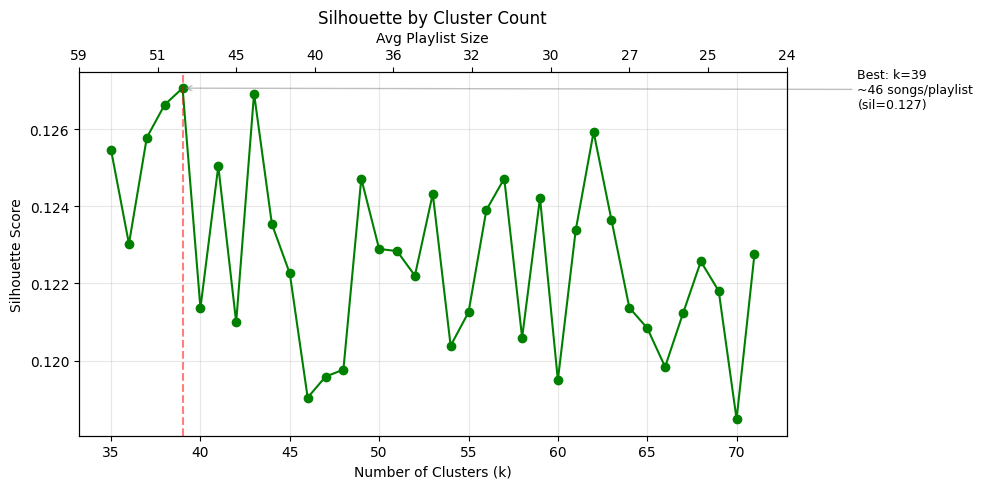


Top 5 by silhouette:
 k  avg_playlist_size  silhouette
39               45.7    0.127063
43               41.5    0.126924
38               46.9    0.126634
62               28.8    0.125928
37               48.2    0.125782


In [5]:
# === RUN EVALUATION ===
eval_df = evaluate_k_range(df_playlist_features, k_range, feature_weights=FEATURE_WEIGHTS, feature_names=FEATURES)
eval_df['avg_playlist_size'] = (n_songs / eval_df['k']).round(1)

best_k = plot_silhouette(eval_df, n_songs)

print(f"\nTop 5 by silhouette:")
print(eval_df.nlargest(5, 'silhouette')[['k', 'avg_playlist_size', 'silhouette']].to_string(index=False))

### Step 2: Get partition params

In [6]:
def get_partition_params(n_songs, best_k, tolerance=0.2):
    """
    Get min/max cluster sizes for a specific k with ±tolerance band.
    """
    avg_size = n_songs / best_k
    min_size = math.floor(avg_size * (1 - tolerance))
    max_size = math.ceil(avg_size * (1 + tolerance))
    
    print(f"Clusters: {best_k}")
    print(f"Avg size: {avg_size:.1f} songs")
    print(f"Allowed range: {min_size}-{max_size} songs (±{tolerance:.0%})")
    
    return min_size, max_size

# Get min and max size for best k
min_size, max_size = get_partition_params(n_songs, best_k, tolerance=0.2)

Clusters: 39
Avg size: 45.7 songs
Allowed range: 36-55 songs (±20%)


#### Step 3: Partition using best k and params

In [7]:
def partition_playlist(
    df_playlist_features,
    k_clusters,
    min_size,
    max_size,
    feature_weights=None
):
    """
    Partition into balanced clusters using pre-scaled data.
    """
    # Get column names from the actual DataFrame
    feature_names = list(df_playlist_features.columns)
    
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df_playlist_features)
    X = X_scaled.copy()
    
    # --- Apply feature weights ---
    if feature_weights:
        for feature, weight in feature_weights.items():
            if feature in feature_names:
                idx = feature_names.index(feature)
                X[:, idx] *= weight
    
    # --- Cluster in scaled space ---
    kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=50)
    initial_clusters = kmeans.fit_predict(X)
    distances = kmeans.transform(X)
    
    # --- Balance clusters ---
    clusters, n_iterations = _balance_clusters(
        initial_clusters, distances, min_size, max_size
    )
    
    # --- Print results ---
    cluster_counts = pd.Series(clusters).value_counts().sort_index()
    print(f"\nBalanced in {n_iterations} iterations")
    print(f"\nCLUSTER SIZES")
    print("=" * 50)
    print(f"Min: {cluster_counts.min()}, Max: {cluster_counts.max()}, "
          f"Mean: {cluster_counts.mean():.1f}")
    print(f"\nAll clusters in [{min_size}, {max_size}]: "
          f"{(cluster_counts >= min_size).all() and (cluster_counts <= max_size).all()}")
    print(f"\n{cluster_counts.to_string()}")
    
    return {
        'kmeans': kmeans,
        'initial_clusters': initial_clusters,
        'clusters': clusters,
        'n_clusters': k_clusters,
        'cluster_counts': cluster_counts
    }


def _balance_clusters(clusters, distances, min_size, max_size, max_iterations=500):
    """Redistribute points to balance cluster sizes."""
    clusters = clusters.copy()
    k_clusters = distances.shape[1]

    for iteration in range(max_iterations):
        counts = np.bincount(clusters, minlength=k_clusters)

        if counts.min() >= min_size and counts.max() <= max_size:
            return clusters, iteration

        biggest = np.argmax(counts)
        smallest = np.argmin(counts)

        if counts[biggest] > max_size:
            in_biggest = np.where(clusters == biggest)[0]
            dist_to_current = distances[in_biggest, biggest]
            most_distant_idx = in_biggest[np.argmax(dist_to_current)]

            point_distances = distances[most_distant_idx]
            sorted_clusters = np.argsort(point_distances)
            for next_cluster in sorted_clusters:
                if next_cluster != biggest and counts[next_cluster] < max_size:
                    clusters[most_distant_idx] = next_cluster
                    break

        elif counts[smallest] < min_size:
            not_in_smallest = np.where(clusters != smallest)[0]
            dist_to_smallest = distances[not_in_smallest, smallest]

            sorted_indices = np.argsort(dist_to_smallest)
            for idx in sorted_indices:
                point_idx = not_in_smallest[idx]
                current_cluster = clusters[point_idx]
                if counts[current_cluster] > min_size:
                    clusters[point_idx] = smallest
                    break

    print(f"Warning: Could not fully balance after {max_iterations} iterations")
    return clusters, max_iterations


In [8]:
# Get results
results = partition_playlist(df_playlist_features,
                             k_clusters=best_k,
                             min_size=min_size, 
                             max_size=max_size, 
                             feature_weights=FEATURE_WEIGHTS
                             )

# Add cluster labels to results and plot
df_playlist_results['Cluster'] = results['clusters']

# Create dictionary of playlists
playlists_spotify_api = {
    f"Playlist_{i+1}": df_playlist_results[df_playlist_results['Cluster'] == i]
        .sort_values(['BPM', 'Valence', 'Dance']).reset_index(drop=True)
        .assign(Track=lambda df: range(1, len(df) + 1))
    for i in range(results['n_clusters'])
}

# Create dataframe from playlists
df_playlists_spotify_api = pd.concat(playlists_spotify_api.values(), ignore_index=True)
df_playlists_spotify_api.to_csv('../results/playlists_spotify_api.csv', index=False)

df_playlists_spotify_api



Balanced in 230 iterations

CLUSTER SIZES
Min: 36, Max: 55, Mean: 45.7

All clusters in [36, 55]: True

0     38
1     54
2     36
3     44
4     52
5     46
6     36
7     55
8     55
9     55
10    55
11    40
12    36
13    55
14    36
15    44
16    51
17    37
18    47
19    36
20    55
21    44
22    36
23    48
24    55
25    36
26    47
27    53
28    50
29    55
30    36
31    36
32    55
33    47
34    55
35    43
36    36
37    39
38    50


,Spotify Track Id,Song,Artist,Album,Playlist,Album Year,BPM,Dance,Energy,Valence,Acoustic,Loud (Db),Album Year,Popularity,Cluster,Track
0,0tyR7Bu9P086aWBFZ4QJoo,Monsters (feat. blackbear),"All Time Low,blackbear","Wake Up, Sunshine",Liked Songs,2020,79,37,85,78,5,-3,2020,71,0,1
1,1Dr1fXbc2IxaK1Mu8P8Khz,When I Come Around,Green Day,Dookie,Rock,1994,98,53,91,81,2,-4,1994,79,0,2
2,75aLTVBSGIquqzQ6AkmK3Q,Smells Like Teen Spirit,Nirvana,Nevermind,Rock,1991,117,50,91,72,0,-5,1991,49,0,3
3,0rmGAIH9LNJewFw7nKzZnc,You Give Love A Bad Name,Bon Jovi,Slippery When Wet,Rock,1986,123,54,96,81,7,-3,1986,77,0,4
4,5qGwqO0lkbBXw4xNfzT7SF,Spice Up Your Life,Spice Girls,Spiceworld,Pop,1997,124,56,99,68,1,-5,1997,67,0,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1779,1TBIHWmr1r34J2s0eSfA7U,All or Nothing,O-Town,O-Town,Pop,2001,127,64,47,25,21,-5,2001,55,38,46
1780,3kG6GPkDkV2RQTm9QdYN9Z,Desire,MEG MYERS,Sorry,Liked Songs,2015,132,62,61,17,0,-5,2015,64,38,47
1781,42JRoxbDZJh3nfoKwj0wEz,Seven,Rainbow Kitten Surprise,Seven + Mary,Rock,2013,136,64,53,19,5,-7,2013,57,38,48
1782,3B7i9OKRRmIsSBHEbJz58Y,Grind With Me,Pretty Ricky,Bluestars,Rap-R&B,2005,137,70,54,19,0,-6,2005,67,38,49


In [9]:
# Print cluster feature profiles
print("=" * 50)
print("CLUSTER FEATURE PROFILES")
print("=" * 50)
def get_series(df, col_name):
    """Extract a clean numeric Series, handling duplicate columns."""
    col = df.loc[:, col_name]
    ser = col.iloc[:, 0] if isinstance(col, pd.DataFrame) else col
    return pd.to_numeric(ser, errors='coerce')

for name, df_cluster in playlists_spotify_api.items():
    print(f"\n{name} (n={len(df_cluster)})")
    
    mean_vals = {}
    std_vals = {}
    range_vals = {}
    
    for f in FEATURES:
        ser = get_series(df_cluster, f)
        if ser.notna().any():
            mean_vals[f] = round(float(ser.mean()), 2)
            std_vals[f] = round(float(ser.std()), 2)
            range_vals[f] = (round(float(ser.min()), 2), round(float(ser.max()), 2))
        else:
            mean_vals[f] = None
            std_vals[f] = None
            range_vals[f] = (None, None)
    
    print(f"  Mean:  {mean_vals}")
    print(f"  Std:   {std_vals}")
    print(f"  Range: {range_vals}")

CLUSTER FEATURE PROFILES

Playlist_1 (n=38)
  Mean:  {'BPM': 158.55, 'Dance': 48.42, 'Energy': 88.32, 'Valence': 75.66, 'Acoustic': 6.0, 'Loud (Db)': -4.42, 'Album Year': 2000.55, 'Popularity': 69.58}
  Std:   {'BPM': 28.98, 'Dance': 6.24, 'Energy': 9.07, 'Valence': 7.14, 'Acoustic': 9.55, 'Loud (Db)': 1.64, 'Album Year': 13.55, 'Popularity': 11.13}
  Range: {'BPM': (79.0, 205.0), 'Dance': (36.0, 59.0), 'Energy': (60.0, 99.0), 'Valence': (64.0, 94.0), 'Acoustic': (0.0, 34.0), 'Loud (Db)': (-9.0, -2.0), 'Album Year': (1970.0, 2025.0), 'Popularity': (35.0, 85.0)}

Playlist_2 (n=54)
  Mean:  {'BPM': 119.24, 'Dance': 63.15, 'Energy': 63.5, 'Valence': 36.69, 'Acoustic': 17.24, 'Loud (Db)': -7.11, 'Album Year': 2013.7, 'Popularity': 32.17}
  Std:   {'BPM': 20.33, 'Dance': 5.94, 'Energy': 11.63, 'Valence': 6.3, 'Acoustic': 16.79, 'Loud (Db)': 1.8, 'Album Year': 6.81, 'Popularity': 15.4}
  Range: {'BPM': (78.0, 160.0), 'Dance': (50.0, 78.0), 'Energy': (40.0, 90.0), 'Valence': (23.0, 49.0), 'Ac